# Artificial Intelligence – Exercise 1
### Kaggle Dataset: International Football Results (1872–2024)
[https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

## Step 1: Load the CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


---
## Basic Exploration
We use core pandas functions — `.shape`, `.min()`, `.max()`, and `.value_counts()` — to understand the scope and structure of the dataset.

### How many matches are in the dataset?

`.shape` returns a tuple of `(rows, columns)`. The first element is the total number of match records.

In [2]:
print(f'Shape: {df.shape}')
print(f'Total matches: {df.shape[0]}')

Shape: (49071, 9)
Total matches: 49071


### What is the earliest and latest year in the data?

The `date` column stores ISO-format strings (`YYYY-MM-DD`). `.min()` and `.max()` perform lexicographic comparison, which works correctly for this date format.

In [3]:
print(f"Earliest match: {df['date'].min()}")
print(f"Latest match:   {df['date'].max()}")

Earliest match: 1872-11-30
Latest match:   2026-01-26


### How many unique countries are there?

A country can appear as either the home or away team. We concatenate both columns before calling `.nunique()` to avoid under-counting teams that only appear on one side.

In [4]:
all_teams = pd.concat([df['home_team'], df['away_team']])
print(f'Unique countries/territories: {all_teams.nunique()}')

Unique countries/territories: 333


### Which team appears most frequently as home team?

`.value_counts()` returns a Series sorted by frequency descending. `.head(5)` limits the output to the top five teams.

In [5]:
df['home_team'].value_counts().head(5)

home_team
Brazil         610
Argentina      599
Mexico         596
Germany        552
South Korea    549
Name: count, dtype: int64

---
## Goals Analysis
We create a `total_goals` column by summing `home_score` and `away_score`, then use it to explore scoring patterns across all matches.

In [6]:
df['total_goals'] = df['home_score'] + df['away_score']
df[['home_score', 'away_score', 'total_goals']].head()

,home_score,away_score,total_goals
0,0,0,0
1,4,2,6
2,2,1,3
3,2,2,4
4,3,0,3


### What is the average number of goals per match?

`.mean()` computes the arithmetic mean across all rows in the `total_goals` column.

In [7]:
avg = df['total_goals'].mean()
print(f'Average goals per match: {avg:.2f}')

Average goals per match: 2.94


### What is the highest scoring match?

`.idxmax()` returns the integer index of the row with the highest `total_goals` value. We pass this to `.loc[]` to retrieve the complete record.

In [8]:
max_row = df.loc[df['total_goals'].idxmax()]
print(f"{max_row['home_team']} {int(max_row['home_score'])} - "
      f"{int(max_row['away_score'])} {max_row['away_team']}")
print(f"Date: {max_row['date']}  |  Total goals: {int(max_row['total_goals'])}")

Australia 31 - 0 American Samoa
Date: 2001-04-11  |  Total goals: 31


### Are more goals scored at home or away?

`.sum()` totals all values in a column. Comparing the two sums tells us which side scores more overall.

In [9]:
home_goals = df['home_score'].sum()
away_goals = df['away_score'].sum()
print(f'Total home goals: {home_goals:,}')
print(f'Total away goals: {away_goals:,}')
print(f'Home teams score {home_goals - away_goals:,} more goals than away teams.')

Total home goals: 86,182
Total away goals: 58,011
Home teams score 28,171 more goals than away teams.


### What is the most common total goals value?

`.mode()` returns the most frequently occurring value(s). Index `[0]` retrieves the primary mode.

In [10]:
mode_val = df['total_goals'].mode()[0]
print(f'Most common total goals in a match: {mode_val}')

Most common total goals in a match: 2


---
## Match Results
We define a helper function and apply it row-by-row using `.apply()` to classify each match as a Home Win, Away Win, or Draw.

In [11]:
def match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(match_result, axis=1)
df[['home_team', 'away_team', 'home_score', 'away_score', 'result']].head()

,home_team,away_team,home_score,away_score,result
0,Scotland,England,0,0,Draw
1,England,Scotland,4,2,Home Win
2,Scotland,England,2,1,Home Win
3,England,Scotland,2,2,Draw
4,Scotland,England,3,0,Home Win


### What percentage of matches are home wins?

`normalize=True` returns proportions; multiplying by 100 converts to percentages.

In [12]:
result_counts = df['result'].value_counts()
result_pct    = df['result'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': result_counts, 'Percentage (%)': result_pct.round(2)})
print(summary)

          Count  Percentage (%)
result                         
Home Win  24043           49.00
Away Win  13872           28.27
Draw      11156           22.73


### Does home advantage exist?

We compare the number of home wins vs. away wins and the total goals scored on each side. A consistent edge for the home team across both metrics confirms the existence of home advantage.

In [13]:
hw = result_counts.get('Home Win', 0)
aw = result_counts.get('Away Win', 0)
print(f'Home wins: {hw:,}  ({hw/len(df)*100:.1f}%)')
print(f'Away wins: {aw:,}  ({aw/len(df)*100:.1f}%)')
print(f'\nConclusion: Home advantage EXISTS — home teams win {hw/aw:.1f}x more often than away teams.')

Home wins: 24,043  (49.0%)
Away wins: 13,872  (28.3%)

Conclusion: Home advantage EXISTS — home teams win 1.7x more often than away teams.


### Which country has the most wins historically?

We count wins separately from `home_team` and `away_team`, then combine them with `.add(fill_value=0)` to get each country's total wins.

In [14]:
home_wins  = df[df['result'] == 'Home Win'].groupby('home_team').size()
away_wins  = df[df['result'] == 'Away Win'].groupby('away_team').size()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

print('Top 10 countries by all-time wins:')
print(total_wins.head(10).astype(int))

Top 10 countries by all-time wins:
Brazil         669
England        623
Germany        595
Argentina      586
Sweden         539
South Korea    536
Mexico         510
Italy          474
France         474
Hungary        469
dtype: int32


---
## Visualisations

### Figure 1 – Histogram of Goals Per Match

A histogram of `total_goals` shows the distribution of scoring across all matches. We expect a right-skewed shape since very high-scoring games are rare.

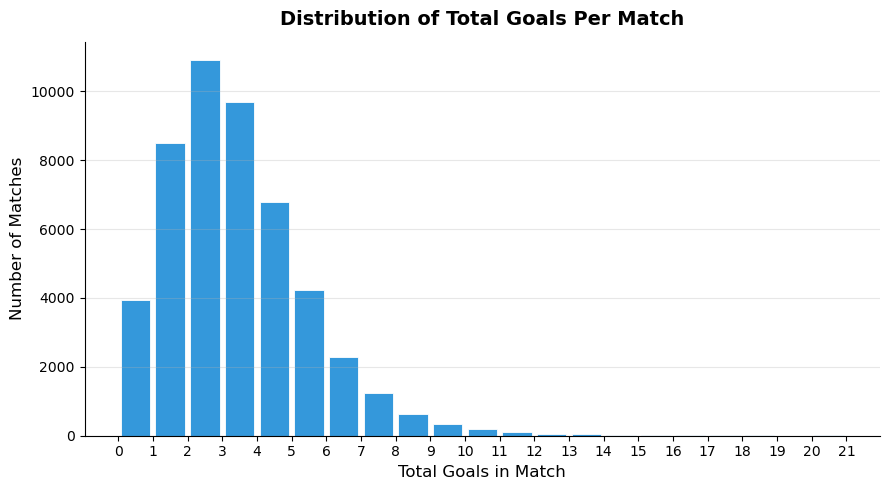

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['total_goals'], bins=range(0, 22), color='#3498db',
        edgecolor='white', linewidth=0.6, rwidth=0.85)
ax.set_title('Distribution of Total Goals Per Match', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Goals in Match', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_xticks(range(0, 22))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_goals_histogram.png', dpi=140)
plt.show()

### Figure 2 – Bar Chart of Match Outcomes

A bar chart comparing the three outcome categories makes the scale of home advantage immediately visible.

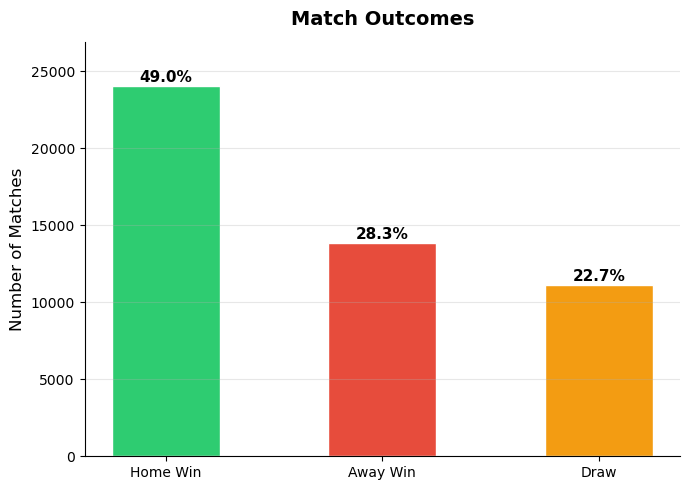

In [16]:
outcome_colors = {'Home Win': '#2ecc71', 'Away Win': '#e74c3c', 'Draw': '#f39c12'}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(result_counts.index, result_counts.values,
              color=[outcome_colors[r] for r in result_counts.index],
              width=0.5, edgecolor='white')

for bar, val in zip(bars, result_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 250,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Match Outcomes', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_ylim(0, result_counts.max() * 1.12)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_match_outcomes.png', dpi=140)
plt.show()

### Figure 3 – Top 10 Teams by Total Wins

A horizontal bar chart makes long country names easy to read and allows quick comparison of win totals across the leading nations.

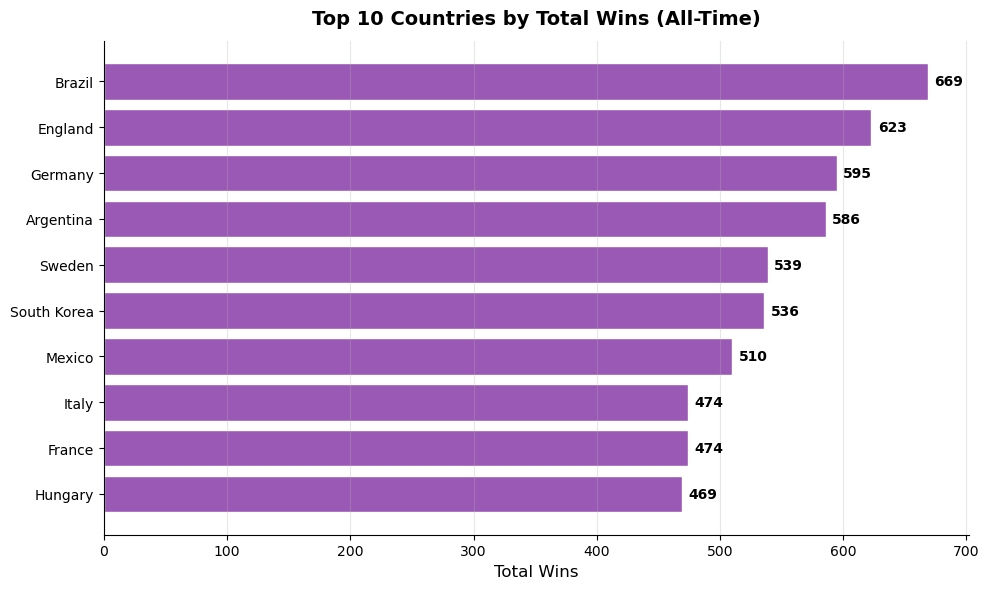

In [17]:
top10 = total_wins.head(10).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color='#9b59b6', edgecolor='white')

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Countries by Total Wins (All-Time)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Wins', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_top10_wins.png', dpi=140)
plt.show()

---
## Summary of Findings
| Question | Answer |
|---|---|
| Total matches | 49,071 |
| Date range | 30 Nov 1872 – 26 Jan 2026 |
| Unique countries | 333 |
| Most frequent home team | Brazil (610 matches) |
| Average goals per match | 2.94 |
| Highest scoring match | Australia 31–0 American Samoa (11 Apr 2001) |
| Home vs away goals | 86,182 vs 58,011 |
| Most common scoreline total | 2 goals |
| Home win % | 49.0% |
| Away win % | 28.3% |
| All-time most wins | Brazil (669) |
